# Pedestrian Count Analysis - La Trobe Street vs Lonsdale Street

Author - Isaac McKissack

Source - https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour

In [3]:
#importing packages
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from scipy.signal import find_peaks
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [4]:
#importing pedestrian data
pedestrian_data_raw = pd.read_csv("../data/raw/pedestrian-counting-system-monthly-counts-per-hour.csv")

In [5]:
#Data Head
pedestrian_data_raw.head(5)

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,1091420250121,109,2025-01-21,14,127,87,214,LatWill_T,"-37.81193681, 144.95621105"
1,109220250801,109,2025-08-01,2,12,7,19,LatWill_T,"-37.81193681, 144.95621105"
2,671520241102,67,2024-11-02,15,371,682,1053,FLDegS_T,"-37.81688755, 144.96562569"
3,672020251018,67,2025-10-18,20,208,312,520,FLDegS_T,"-37.81688755, 144.96562569"
4,682020250110,68,2025-01-10,20,242,241,483,FLDegN_T,"-37.8168479, 144.96559789"


In [6]:
# Row Count
pedestrian_data_raw.shape
# 9 columns, 1,610,006 observations

(1610006, 9)

In [7]:
# Scanning for nulls
pedestrian_data_raw.isna().sum()

id                     0
location_id            0
sensing_date           0
hourday                0
direction_1            0
direction_2            0
pedestriancount        0
sensor_name        26265
location           26265
dtype: int64

In [8]:
# Isolating for sensor_name with valid rows
pedestrian_data_clean = pedestrian_data_raw[pedestrian_data_raw['sensor_name'].notna()]
# Split dates
pedestrian_data_clean['year-month'] = pd.to_datetime(pedestrian_data_clean['sensing_date']).dt.strftime('%Y-%b')
pedestrian_data_clean['year'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).year
pedestrian_data_clean['month'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).month
pedestrian_data_clean['day'] = pd.DatetimeIndex(pedestrian_data_clean['sensing_date']).day
# Sort dates???
pedestrian_data_clean = pedestrian_data_clean.sort_values(by=['sensing_date'])
# How to sort the dates so they go properlllyyyyy

pedestrian_data_clean.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,year-month,year,month,day
842513,117920240725,117,2024-07-25,9,203,70,273,Fli114F_T,"-37.81629332, 144.97090877",2024-Jul,2024,7,25
1082657,392120240725,39,2024-07-25,21,33,26,59,AlfPl_T,"-37.81379749, 144.96995745",2024-Jul,2024,7,25
526647,107020240725,107,2024-07-25,0,10,4,14,280Will_T,"-37.81246271, 144.95690188",2024-Jul,2024,7,25
1462118,117620240725,117,2024-07-25,6,29,16,45,Fli114F_T,"-37.81629332, 144.97090877",2024-Jul,2024,7,25
344956,1321420240725,132,2024-07-25,14,128,97,225,King335_T,"-37.81267639, 144.95386444",2024-Jul,2024,7,25


In [9]:
# Per a QGIS analysis of sensor locations, separate into two datasets - Lonsdale St and La Trobe St
# Lonsdale St - sensors 108, 47, 3 in broader buffer area
pedestrian_lonsdale = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin([133,108,56,52,47,3,30])]
pedestrian_lonsdale.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,year-month,year,month,day
1029979,56220240725,56,2024-07-25,2,12,24,36,Lon364_T,"-37.81234775, 144.96153311",2024-Jul,2024,7,25
1079084,1081220240725,108,2024-07-25,12,164,327,491,261Will_T,"-37.81295822, 144.95678789",2024-Jul,2024,7,25
480151,1081320240725,108,2024-07-25,13,157,306,463,261Will_T,"-37.81295822, 144.95678789",2024-Jul,2024,7,25
895770,521020240725,52,2024-07-25,10,114,107,221,Eli263_T,"-37.81252157, 144.9619401",2024-Jul,2024,7,25
1251179,521320240725,52,2024-07-25,13,334,350,684,Eli263_T,"-37.81252157, 144.9619401",2024-Jul,2024,7,25


In [10]:
# La Trobe St - sensors 108, 108, 59, 61, 66, 3 in broader buffer area
pedestrian_latrobe = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin([164,167,132,109,107,108,181,62,187,59,61,66,3])]
pedestrian_latrobe.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,year-month,year,month,day
526647,107020240725,107,2024-07-25,0,10,4,14,280Will_T,"-37.81246271, 144.95690188",2024-Jul,2024,7,25
344956,1321420240725,132,2024-07-25,14,128,97,225,King335_T,"-37.81267639, 144.95386444",2024-Jul,2024,7,25
850548,661720240725,66,2024-07-25,17,1650,1844,3494,QVN_T,"-37.81057846, 144.96444294",2024-Jul,2024,7,25
288438,621720240725,62,2024-07-25,17,290,202,492,Lat224_T,"-37.80996494, 144.96216521",2024-Jul,2024,7,25
330868,66520240725,66,2024-07-25,5,12,20,32,QVN_T,"-37.81057846, 144.96444294",2024-Jul,2024,7,25


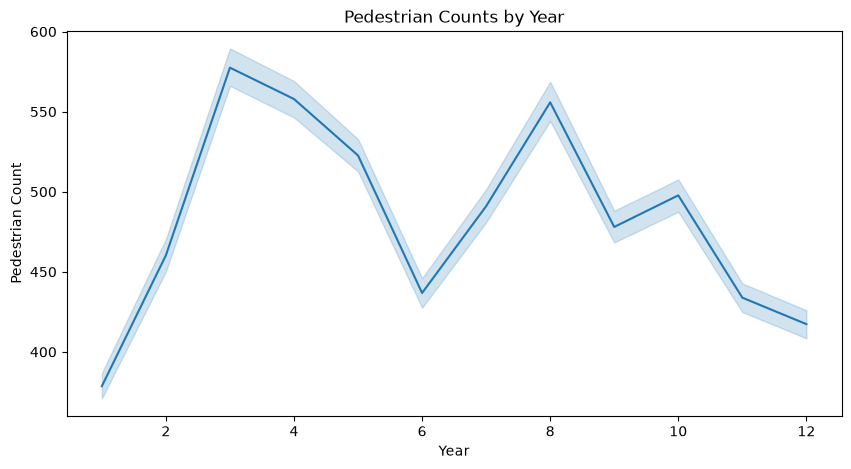

In [11]:
plt.figure(figsize = (10,5))

sns.lineplot(data = pedestrian_latrobe, x = 'month', y = 'pedestriancount')
plt.title("Pedestrian Counts by Year")
plt.xlabel("Year")
plt.ylabel("Pedestrian Count")

plt.show()

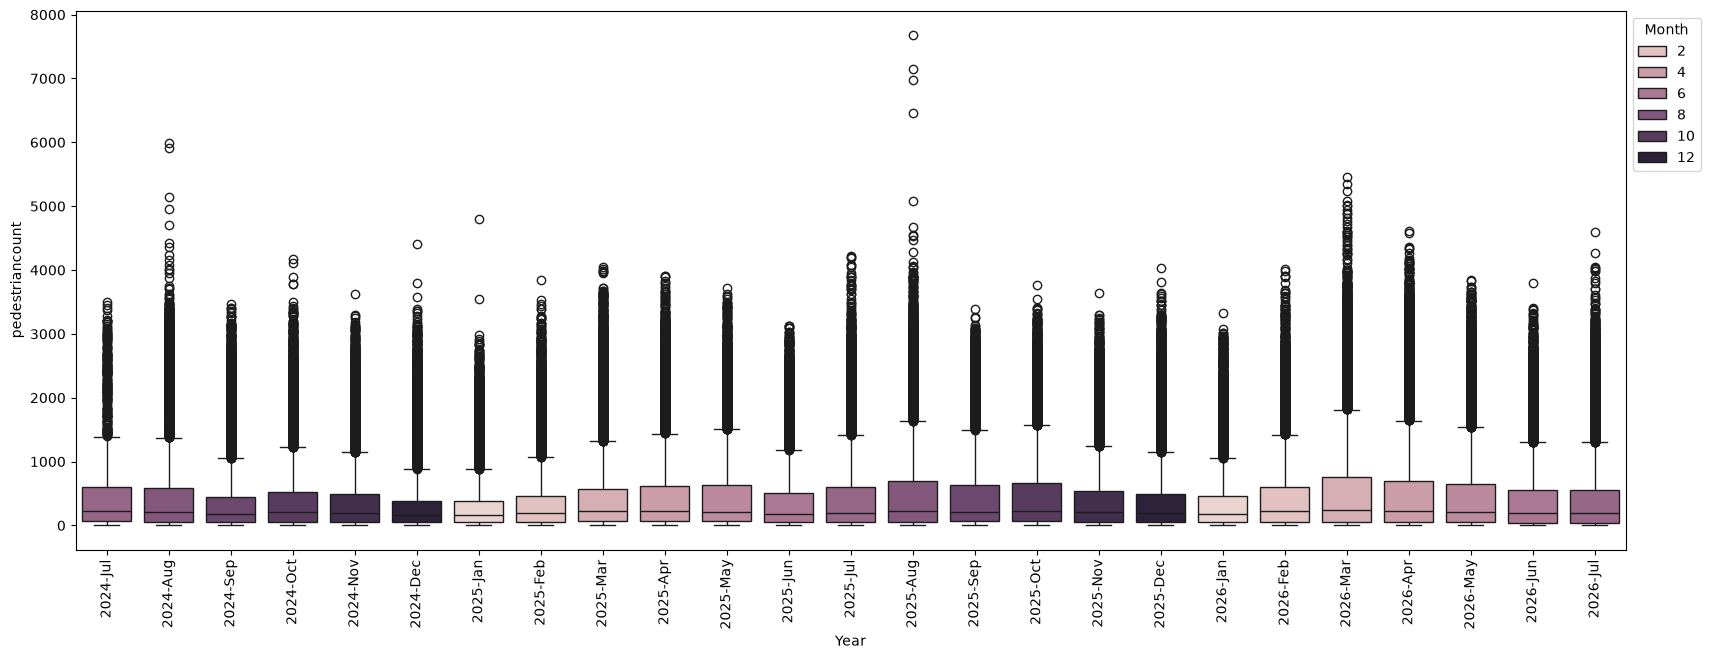

In [12]:
fig, ax = plt.subplots(figsize = (20, 7))

sns.boxplot(data = pedestrian_latrobe, x = 'year-month', y = 'pedestriancount', hue = 'month', ax = ax)
ax.legend(title = 'Month', bbox_to_anchor=(1,1), loc='upper left')
ax.set(xlabel='Year')
plt.xticks(rotation=90)
plt.show()

C:\Users\incar\AppData\Local\Temp\ipykernel_22948\1940090661.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


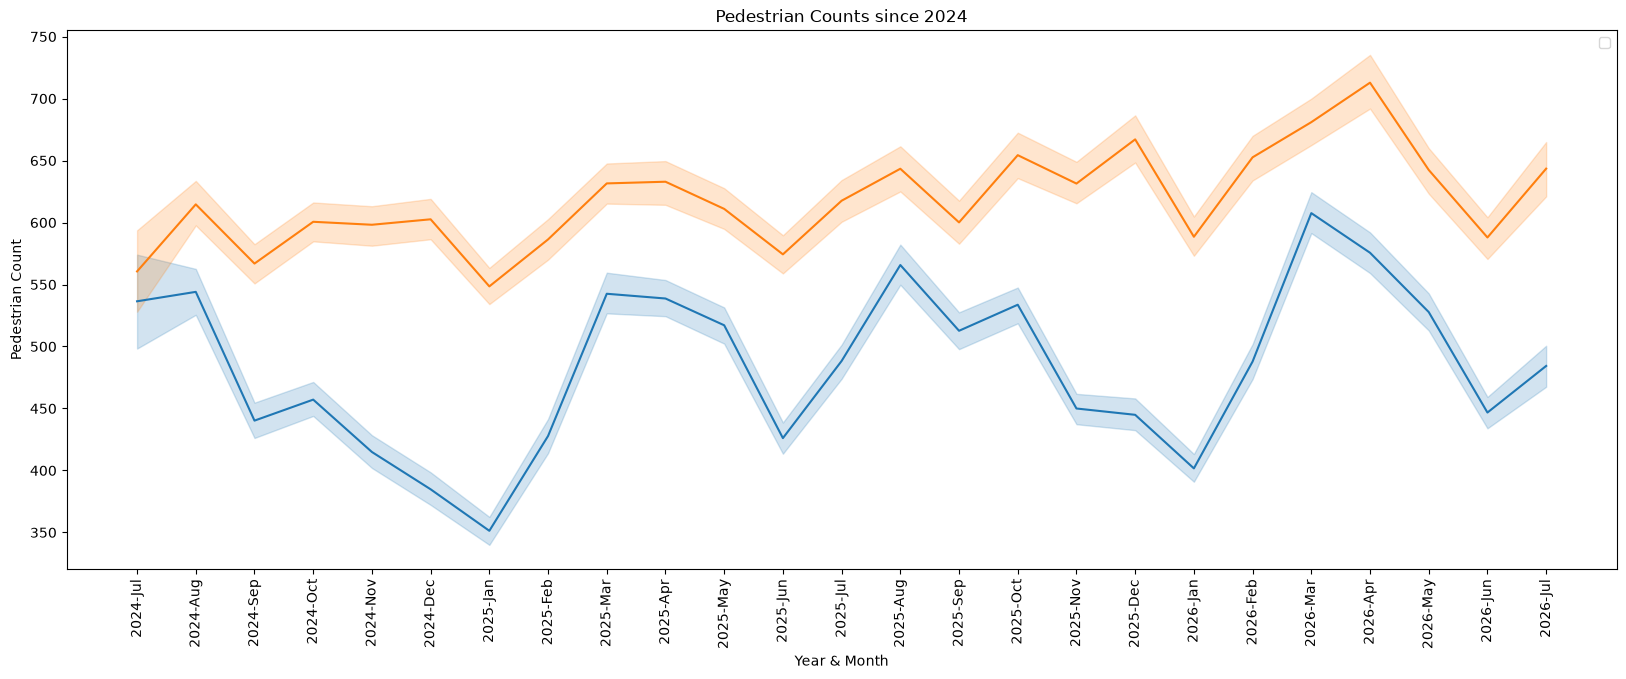

In [13]:
fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = pedestrian_latrobe, x = 'year-month', y = 'pedestriancount', ax = ax)
sns.lineplot(data = pedestrian_lonsdale, x = 'year-month', y = 'pedestriancount')
plt.title("Pedestrian Counts since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation=90)
ax.legend(loc='upper right')
plt.ylabel("Pedestrian Count")

plt.show()